<a href="https://colab.research.google.com/github/gulshat910/-/blob/main/%D0%97%D0%B0%D0%BD%D1%8F%D1%82%D0%B8%D0%B5_2_%D0%9F%D0%B0%D1%80%D1%81%D0%B8%D0%BD%D0%B3_BeautifulSoup_Selenium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Парсинг

In [ ]:
from bs4 import BeautifulSoup
import requests

## BeautifulSoup

### Парсинг текста

Для парсинга текста будем использовать сайт https://pozdravok.com/pozdravleniya/den-rozhdeniya/proza-2.htm. Задача состоит в том, чтобы спарсить только одно поздравление, без какой-либо лишней информации.

In [ ]:
# ссылка на страницу с поздравлениями
url = 'https://pozdravok.com/pozdravleniya/den-rozhdeniya/proza-2.htm'

# выполняем запрос на страницу
response = requests.get(url)
print(response)
print(type(response))

<Response [200]>
<class 'requests.models.Response'>


In [ ]:
# получаем заголовки ответа
headers = response.headers
print(headers)

# получаем куки ответа
cookies = response.cookies
print(cookies)

{'Server': 'nginx', 'Date': 'Fri, 26 Sep 2025 12:43:08 GMT', 'Content-Type': 'text/html; charset=windows-1251', 'Content-Length': '6395', 'Last-Modified': 'Thu, 25 Sep 2025 21:33:52 GMT', 'Connection': 'keep-alive', 'Keep-Alive': 'timeout=18', 'Vary': 'Accept-Encoding', 'ETag': '"68d5b540-18fb"', 'Content-Encoding': 'gzip', 'Expires': 'Fri, 26 Sep 2025 21:33:52 GMT', 'Cache-Control': 'max-age=31844', 'Strict-Transport-Security': 'max-age=0'}
<RequestsCookieJar[]>


In [ ]:
from pprint import pprint

# получаем разметку html ответа
html = response.text
pprint(html)

('<!doctype html><html lang="ru"><head><title>Поздравления с днем рождения '
 'своими словами</title><link rel="stylesheet" type="text/css" '
 'href="//www.pozdravok.com/main.css"><meta charset="windows-1251"><meta '
 'name="viewport" content="width=device-width, initial-scale=1.0"><meta '
 'http-equiv="Content-Type" content="text/html; charset=windows-1251"><meta '
 'http-equiv="content-language" content="ru"><link rel="preload" as="style" '
 'href="//www.pozdravok.com/main.css"><link rel="preload" as="script" '
 'href="//www.pozdravok.com/script.js"><link rel="preload" as="image" '
 'href="/pic/icons2.png"><link rel="icon" href="/favicon.ico"><link rel="home" '
 'title="Поздравления на Поздравок" href="https://www.pozdravok.com/"><link '
 'rel="alternate" type="application/rss+xml" title="Праздники в RSS" '
 'href="/prazdniki.rss"><meta name="color-scheme" content="light dark"><link '
 'rel="first" href="/pozdravleniya/den-rozhdeniya/proza.htm"><link rel="prev" '
 'title="Предыдущая 

In [ ]:
html

'<!doctype html><html lang="ru"><head><title>Поздравления с днем рождения своими словами</title><link rel="stylesheet" type="text/css" href="//www.pozdravok.com/main.css"><meta charset="windows-1251"><meta name="viewport" content="width=device-width, initial-scale=1.0"><meta http-equiv="Content-Type" content="text/html; charset=windows-1251"><meta http-equiv="content-language" content="ru"><link rel="preload" as="style" href="//www.pozdravok.com/main.css"><link rel="preload" as="script" href="//www.pozdravok.com/script.js"><link rel="preload" as="image" href="/pic/icons2.png"><link rel="icon" href="/favicon.ico"><link rel="home" title="Поздравления на Поздравок" href="https://www.pozdravok.com/"><link rel="alternate" type="application/rss+xml" title="Праздники в RSS" href="/prazdniki.rss"><meta name="color-scheme" content="light dark"><link rel="first" href="/pozdravleniya/den-rozhdeniya/proza.htm"><link rel="prev" title="Предыдущая - Поздравления с днем рождения" href="/pozdravleniya/

- Информационные ответы (100–199)
- Успешные ответы (200–299)
- Сообщения о перенаправлении (300–399)
- Ответы об ошибках клиента (400–499)
- Ответы об ошибках сервера (500–599)



---



- 200 OK - запрос успешно выполнен
- 301 Moved Permanently - запрашиваемый ресурс был постоянно перемещен по другому адресу
- 302 Found - запрашиваемый ресурс был временно перемещен по другому адресу
- 304 Not Modified - запрашиваемый ресурс не изменился с последнего запроса и не нуждается в повторной передаче
- 400 Bad Request - запрос неверно сформирован или содержит ошибки
- 401 Unauthorized - запрос требует аутентификации пользователя
- 403 Forbidden - сервер отказывает в выполнении запроса по какой-то причине
- 404 Not Found - запрашиваемый ресурс не найден на сервере
- 500 Internal Server Error - сервер столкнулся с внутренней ошибкой и не может выполнить запрос
- 503 Service Unavailable - сервер временно недоступен из-за перегрузки или технических проблем


---



---




In [ ]:
# парсинг кода страницы
bs = BeautifulSoup(response.text, "html.parser")
print(bs)

<!DOCTYPE html>
<html lang="ru"><head><title>Поздравления с днем рождения своими словами</title><link href="//www.pozdravok.com/main.css" rel="stylesheet" type="text/css"/><meta charset="utf-8"/><meta content="width=device-width, initial-scale=1.0" name="viewport"/><meta content="text/html; charset=utf-8" http-equiv="Content-Type"/><meta content="ru" http-equiv="content-language"/><link as="style" href="//www.pozdravok.com/main.css" rel="preload"/><link as="script" href="//www.pozdravok.com/script.js" rel="preload"/><link as="image" href="/pic/icons2.png" rel="preload"/><link href="/favicon.ico" rel="icon"/><link href="https://www.pozdravok.com/" rel="home" title="Поздравления на Поздравок"/><link href="/prazdniki.rss" rel="alternate" title="Праздники в RSS" type="application/rss+xml"/><meta content="light dark" name="color-scheme"/><link href="/pozdravleniya/den-rozhdeniya/proza.htm" rel="first"/><link href="/pozdravleniya/den-rozhdeniya/proza.htm" rel="prev" title="Предыдущая - Поздр

In [ ]:
bs.prettify()

'<!DOCTYPE html>\n<html lang="ru">\n <head>\n  <title>\n   Поздравления с днем рождения своими словами\n  </title>\n  <link href="//www.pozdravok.com/main.css" rel="stylesheet" type="text/css"/>\n  <meta charset="utf-8"/>\n  <meta content="width=device-width, initial-scale=1.0" name="viewport"/>\n  <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>\n  <meta content="ru" http-equiv="content-language"/>\n  <link as="style" href="//www.pozdravok.com/main.css" rel="preload"/>\n  <link as="script" href="//www.pozdravok.com/script.js" rel="preload"/>\n  <link as="image" href="/pic/icons2.png" rel="preload"/>\n  <link href="/favicon.ico" rel="icon"/>\n  <link href="https://www.pozdravok.com/" rel="home" title="Поздравления на Поздравок"/>\n  <link href="/prazdniki.rss" rel="alternate" title="Праздники в RSS" type="application/rss+xml"/>\n  <meta content="light dark" name="color-scheme"/>\n  <link href="/pozdravleniya/den-rozhdeniya/proza.htm" rel="first"/>\n  <link href="/po

У **BS** есть несколько видов парсеров, которые можно использовать для разбора HTML-документов:

---



* **lxml** является самым быстрым и гибким парсером, но требует установки отдельного пакета.
* **Html5lib** является самым медленным, но наиболее точно воспроизводит поведение браузера при разборе HTML-документов.
* **Html.parser** является встроенным парсером Python, который не требует дополнительных зависимостей, но может пропускать некоторые теги или атрибуты в неправильно сформированном HTML-коде.
* **Xml** является парсером для XML-документов, который также использует lxml, но не подходит для HTML-документов. Выбор парсера зависит от ваших целей и предпочтений.


In [ ]:
!pip install html5lib

Чтобы просмотреть код страницы в браузере Chrome нужно нажать правой кнопкой мыши в окне браузера и выбрать "просмотреть код", либо можно нажать клавишу `f12`.

Благодаря удобному просмотру кода страницы браузера Chrome мы можем найти интересующий нас класс html разметки.
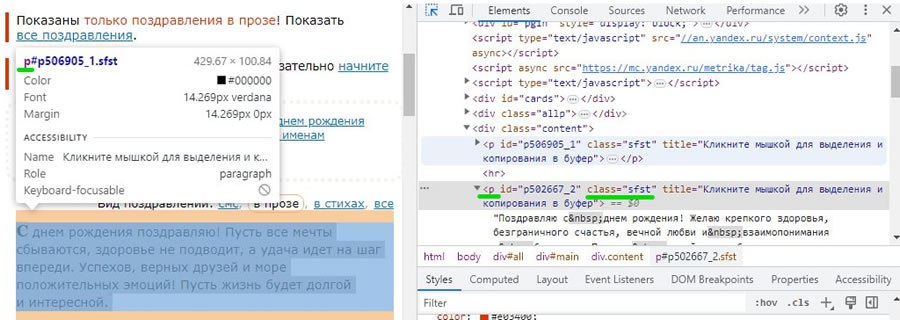

Для поиска элементов в BeautifulSoup используется функция `findAll()`, в которой мы можем указать тег, имя класса, id или конкретную строку.

Здесь используем тег `p`

In [ ]:
sample = bs.findAll('p')
sample

/tmp/ipython-input-1784750921.py:1: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  sample = bs.findAll('p')


[<p class="sfst" id="p112755_1">С днем рождения! Желаю крепкого здоровья, удачи, благополучия, добра, радости, любви, счастья, хорошего настроения, улыбок, ярких впечатлений. Пусть тепло и уют всегда наполняют твой дом, пусть солнечный свет согревает в любую погоду, а желания исполняются при одной мысли о них.</p>,
 <p class="sfst" id="p503855_2">Поздравляю с днем рождения! Желаю, чтобы сил и времени на всё хватало, чтобы океан здоровья был бескрайним, а в душе царил покой. Желаю, чтобы в доме у тебя всегда были благополучие и мир, чтоб все дела и начинания заканчивались только успехом, а близкие и надежные друзья были всегда рядом. Удачи и счастья на жизненном пути, исполнения всех желаний и большой мешок денежек ко всему в придачу!</p>,
 <p class="sfst" id="p554490_3">Поздравляю с днем рождения! Желаю здоровья, душевного благополучия и денежного изобилия. Пусть твои желания будут исполнены, цели достигнуты, а проблемы решены! С днем рождения!</p>,
 <p class="sfst" id="p580181_4">С дн

Добавляем 2 поздравления в список и обьединяем их в одну переменную `res` через пробел

In [ ]:
sam = [p.text for p in sample]
print(sam)
res = ' '.join(sam)
print(res)

['С днем рождения поздравляю! Пусть все мечты сбываются, здоровье не\xa0подводит, а\xa0удача идет на\xa0шаг впереди. Успехов, верных друзей и\xa0море положительных эмоций! Пусть жизнь будет долгой и\xa0интересной.', 'Поздравляю с\xa0днем рождения! Желаю крепкого здоровья, безграничного счастья, вечной любви и\xa0взаимопонимания с\xa0близкими. Пусть в\xa0твоей жизни будет как можно меньше огорчений и\xa0как можно больше радостных событий.']
С днем рождения поздравляю! Пусть все мечты сбываются, здоровье не подводит, а удача идет на шаг впереди. Успехов, верных друзей и море положительных эмоций! Пусть жизнь будет долгой и интересной. Поздравляю с днем рождения! Желаю крепкого здоровья, безграничного счастья, вечной любви и взаимопонимания с близкими. Пусть в твоей жизни будет как можно меньше огорчений и как можно больше радостных событий.


Здесь используем класс `sfst`

In [ ]:
allNews = bs.findAll('p', class_='sfst')

In [ ]:
# выполним небольшую очистку
print(allNews[0].text)

С днем рождения поздравляю! Пусть все мечты сбываются, здоровье не подводит, а удача идет на шаг впереди. Успехов, верных друзей и море положительных эмоций! Пусть жизнь будет долгой и интересной.


In [ ]:
# оставим только текст одного поздравления
print(allNews[0].text.split('Поздравление')[0])

С днем рождения поздравляю! Пусть все мечты сбываются, здоровье не подводит, а удача идет на шаг впереди. Успехов, верных друзей и море положительных эмоций! Пусть жизнь будет долгой и интересной.


### Парсинг изображений

Парсинг изображений будет выполняться с сайта игрушек https://int-games.ru/age_groups/market/balansiry/

In [ ]:
# ссылка на страницу с игрушками
url = 'https://int-games.ru/age_groups/market/balansiry/'

# выполняем запрос на страницу
response = requests.get(url)
print(response)

<Response [200]>


In [ ]:
# парсинг кода страницы
bs = BeautifulSoup(response.text, "html.parser")
print(bs)

<!DOCTYPE html>
<html lang="ru">
<head>
<meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<title>Детские балансиры - Купить балансборды для детей с доставкой по России</title>
<meta content="Закажите деревянные балансировочные доски для детей с доставкой по России. Детские качалки-балансиры, балансборды с лабиринтом в интернет-магазине Интересные игры, приятные цены." name="description"/>
<meta content="" name="keywords"/>
<meta content="index, follow" name="robots"/>
<meta content="width=device-width, initial-scale=1.0" name="viewport"/>
<link href="https://int-games.ru/images/favicon.webp" rel="shortcut icon" type="image/ico"/>
<link href="https://int-games.ru/age_groups/market/balansiry/" rel="canonical"/>
<style>
			@font-face {
				font-family: 'latoregular';
				/*src: url('/templates/ushopmega/fonts/lato-regular-webfont.eot');*/
				src:

На этот раз нас интересует не текст, а ссылки на изображения. Тег изображения - `img`



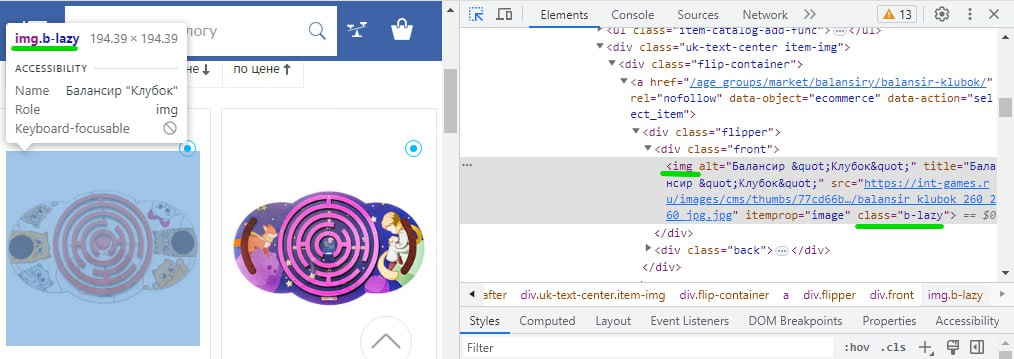

In [ ]:
# <img class="b-lazy" ...>
allimgs = bs.findAll('img', class_='b-lazy')
allimgs[0]

<img alt='Балансир "Клубок"' class="b-lazy" itemprop="image" src="https://int-games.ru/images/cms/thumbs/77cd66b03d99b8ff8446dc7a1cae77b25331d91e/balansir_klubok_260_260_jpg.jpg" title='Балансир "Клубок"'/>

In [ ]:
allimgs[0].get('src')

'https://int-games.ru/images/cms/thumbs/77cd66b03d99b8ff8446dc7a1cae77b25331d91e/balansir_klubok_260_260_jpg.jpg'

In [ ]:
# проходим по всем объектам img
for img in allimgs:

  # достаем только src - url к картинке
  print(img.attrs.get("src"))

https://int-games.ru/images/cms/thumbs/77cd66b03d99b8ff8446dc7a1cae77b25331d91e/balansir_klubok_260_260_jpg.jpg
https://int-games.ru/images/cms/thumbs/eaa6cd063508a79a5c6ee652e19a837f5a24c4d9/balansir_kosmos_260_260_jpg.jpg
https://int-games.ru/images/cms/thumbs/eaa6cd063508a79a5c6ee652e19a837f5a24c4d9/balansir_malen_kij_princ_260_260_jpg.jpg
https://int-games.ru/images/cms/thumbs/77cd66b03d99b8ff8446dc7a1cae77b25331d91e/balansir_safari_260_260_jpg.jpg
https://int-games.ru/images/cms/thumbs/eaa6cd063508a79a5c6ee652e19a837f5a24c4d9/balansir_skazka_260_260_jpg.jpg
https://int-games.ru/images/cms/thumbs/26bea36b583901644f079d0aab2e35332791a8e3/balansir_veselyj_medved_260_260_jpg.jpg
https://int-games.ru/images/cms/thumbs/6d980155dd9f60b9f64dc59afc7f4f6f17d2db85/balansir_detskij_podarok_malyshu_260_260_jpg.jpg


Ссылки на изображения есть, теперь напишем код для сохранения изображений по этим ссылкам

In [ ]:
# для загрузки изображения выполняем get запрос по ссылке изображения
filename = requests.get('https://int-games.ru/images/cms/thumbs/77cd66b03d99b8ff8446dc7a1cae77b25331d91e/balansir_klubok_260_260_jpg.jpg')

# сохраняем файл при помощи контекстного менеджера
with open('img.jpg', "wb") as out:
  out.write(filename.content)

Сохраним все изображения

In [ ]:
# номер изображения
num = 1

# проходим по всем объектам img
for img in allimgs:

  # достаем ссылку на изображение
  img_url = img.attrs.get("src")

  # get запрос
  filename = requests.get(img_url)

  # сохраняем изображение в файл
  with open(f'img_{num}.jpg', "wb") as out:
    out.write(filename.content)

  num+=1

*Изображения загрузились на виртуальную машину гугл колаба*

### Парсинг аудио
*(очень долго грузиться)*

Парсинг аудиозаписей будем делать с сайта https://voicebot.su/ru/category/penie-ptits/

In [ ]:
# ссылка на страницу с звуками пения птиц
url = 'https://voicebot.su/ru/category/penie-ptits/'

# выполняем запрос на страницу
response = requests.get(url)
print(response)

<Response [200]>


In [ ]:
# парсинг кода страницы
bs = BeautifulSoup(response.text, "html.parser")
# print(bs)

Здесь нас интересуют ссылки на скачивание аудио в формате mp3

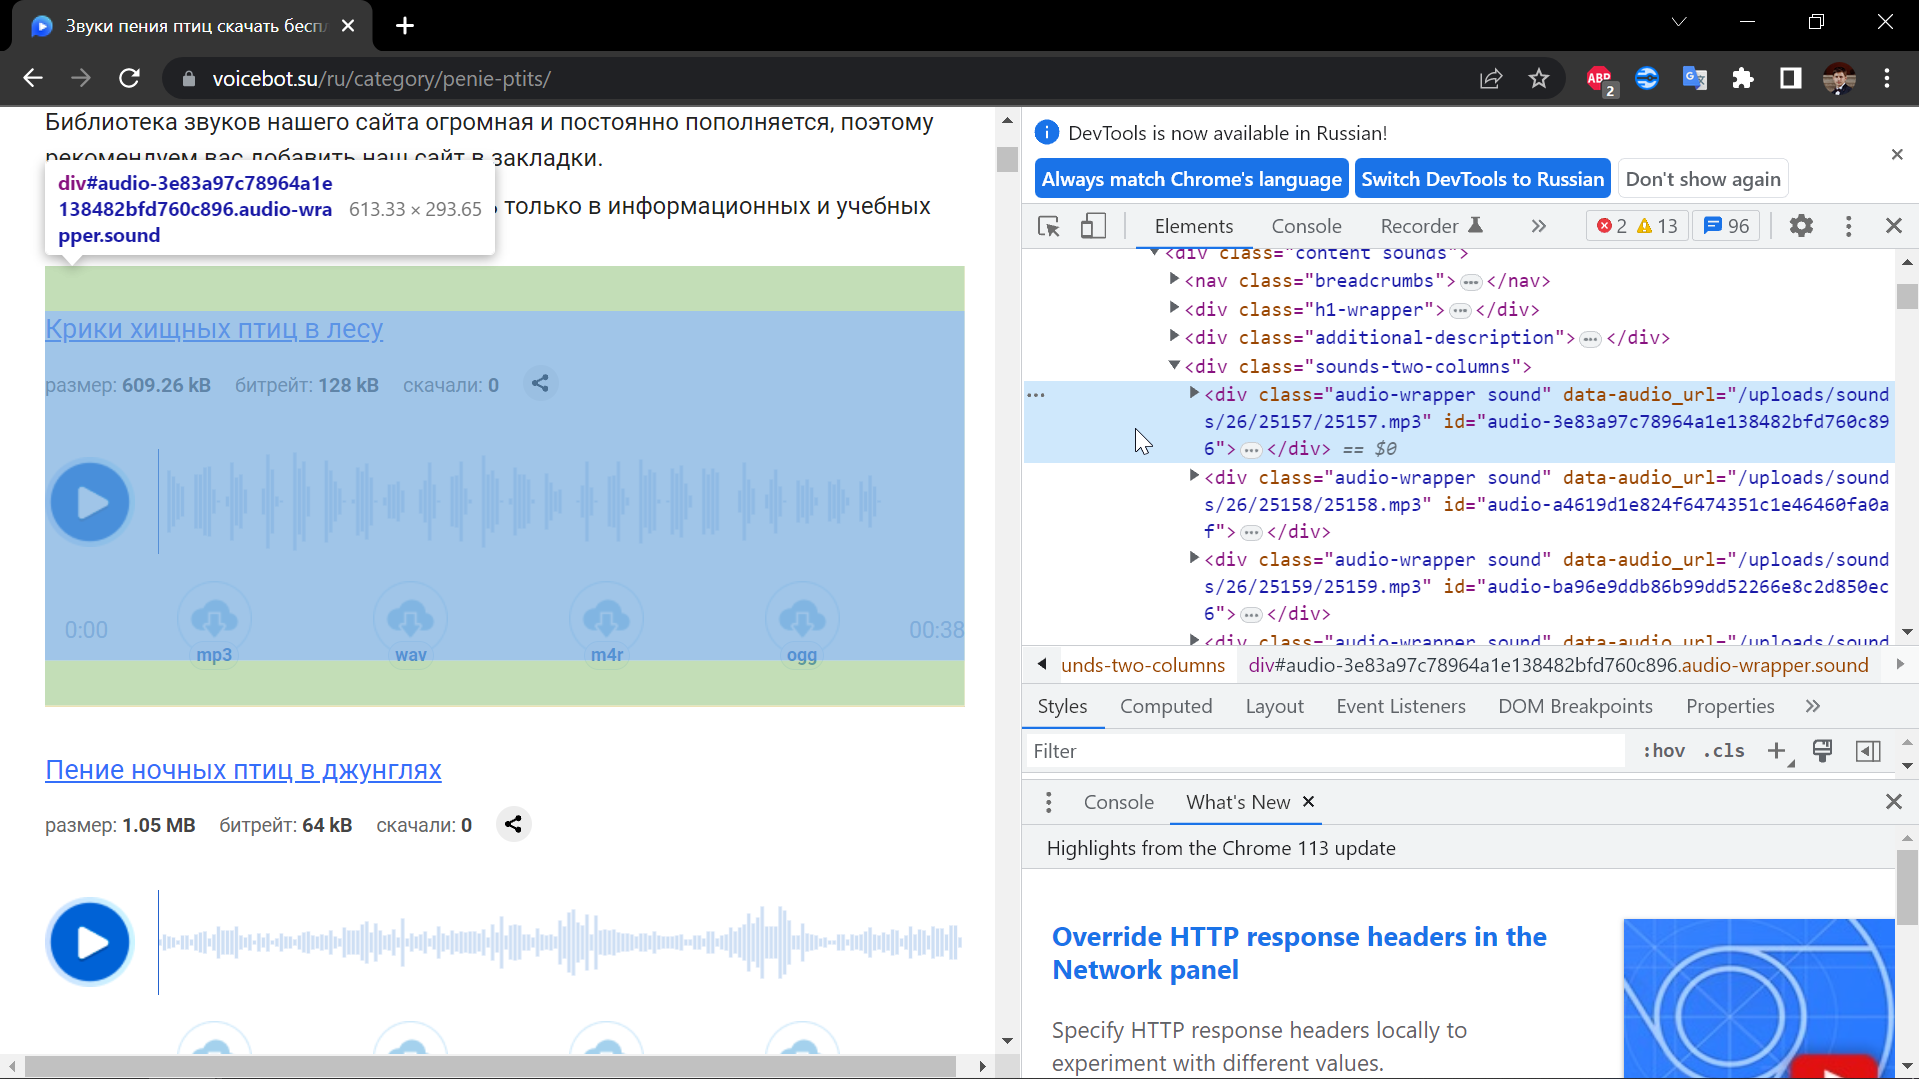

In [ ]:
# <div class="audio-wrapper sound" ...>
alldivs = bs.findAll('div', class_='audio-wrapper sound')
alldivs

[<div class="audio-wrapper sound" data-audio_url="/uploads/sounds/26/25157/25157.mp3" id="audio-3e83a97c78964a1e138482bfd760c896"><div class="audio"><div class="sound-info"><a class="sound-name" href="/ru/sound/25157-sound_02366/">Крики хищных птиц в лесу</a><span class="right"><span>размер: <b>609.26 kB</b></span><span>битрейт: <b>128 kB</b></span><span>скачали: <b>0</b></span><div class="ya-share2" data-curtain="" data-description="Крики хищных птиц в лесу" data-limit="0" data-more-button-type="short" data-services="vkontakte,facebook,odnoklassniki,telegram,twitter,viber,whatsapp" data-size="s" data-title="Крики хищных птиц в лесу" data-url="https://voicebot.su/ru/sound/25157-sound_02366/"></div></span></div><div class="waveform-wrapper"><div class="play-button paused"></div><div class="waveform"></div></div><div class="audio-tools"><div class="duration-current">0:00</div><div class="downloadlist"><div class="audio-download mp3" title="скачать в mp3"></div><div class="audio-download 

In [ ]:
# проходим по всем объектам div класса 'audio-wrapper sound'
for div in alldivs:

  # достаем ссылку на аудиофайл (адрес не полный)
  print(div.attrs.get("data-audio_url"))

/uploads/sounds/26/25157/25157.mp3
/uploads/sounds/26/25158/25158.mp3
/uploads/sounds/26/25159/25159.mp3
/uploads/sounds/26/25160/25160.mp3
/uploads/sounds/26/25161/25161.mp3
/uploads/sounds/26/25162/25162.mp3
/uploads/sounds/26/25163/25163.mp3
/uploads/sounds/26/25164/25164.mp3
/uploads/sounds/26/25165/25165.mp3
/uploads/sounds/26/25166/25166.mp3
/uploads/sounds/26/25167/25167.mp3
/uploads/sounds/26/25168/25168.mp3
/uploads/sounds/26/25169/25169.mp3
/uploads/sounds/26/25170/25170.mp3
/uploads/sounds/26/25171/25171.mp3
/uploads/sounds/26/25172/25172.mp3
/uploads/sounds/26/25173/25173.mp3
/uploads/sounds/26/25174/25174.mp3
/uploads/sounds/26/25175/25175.mp3
/uploads/sounds/26/25176/25176.mp3
/uploads/sounds/26/25177/25177.mp3
/uploads/sounds/26/25178/25178.mp3
/uploads/sounds/26/25179/25179.mp3
/uploads/sounds/26/25180/25180.mp3
/uploads/sounds/26/25181/25181.mp3
/uploads/sounds/26/25182/25182.mp3
/uploads/sounds/26/25183/25183.mp3
/uploads/sounds/26/25184/25184.mp3
/uploads/sounds/26/2

Загрузим и сохраним сразу все аудио

In [ ]:
raw_url = 'https://voicebot.su'
raw_url

'https://voicebot.su'

In [ ]:
# родительский адрес
raw_url = 'https://voicebot.su/'

# номер аудиозаписи
num = 1

# проходим по всем объектам div класса 'audio-wrapper sound'
for div in alldivs:

  # достаем ссылку на аудиофайл
  audio_url = raw_url + div.attrs.get("data-audio_url")

  # get запрос
  filename = requests.get(audio_url)

  # сохраняем аудио в файл
  with open(f'bird_song_{num}.mp3', "wb") as out:
    out.write(filename.content)

  num+=1

### Парсинг видео
*(очень долго грузиться)*

Парсинг видео выполним с сайта https://www.videvo.net/

In [ ]:
# ссылка на страницу с тестовыми видео
url = 'https://www.videvo.net/'

# выполняем запрос на страницу
response = requests.get(url)
print(response)

<Response [200]>


In [ ]:
# парсинг кода страницы
bs = BeautifulSoup(response.text, "html.parser")

Подход тот же - нужно найти ссылки на скачивание файлов в разметке

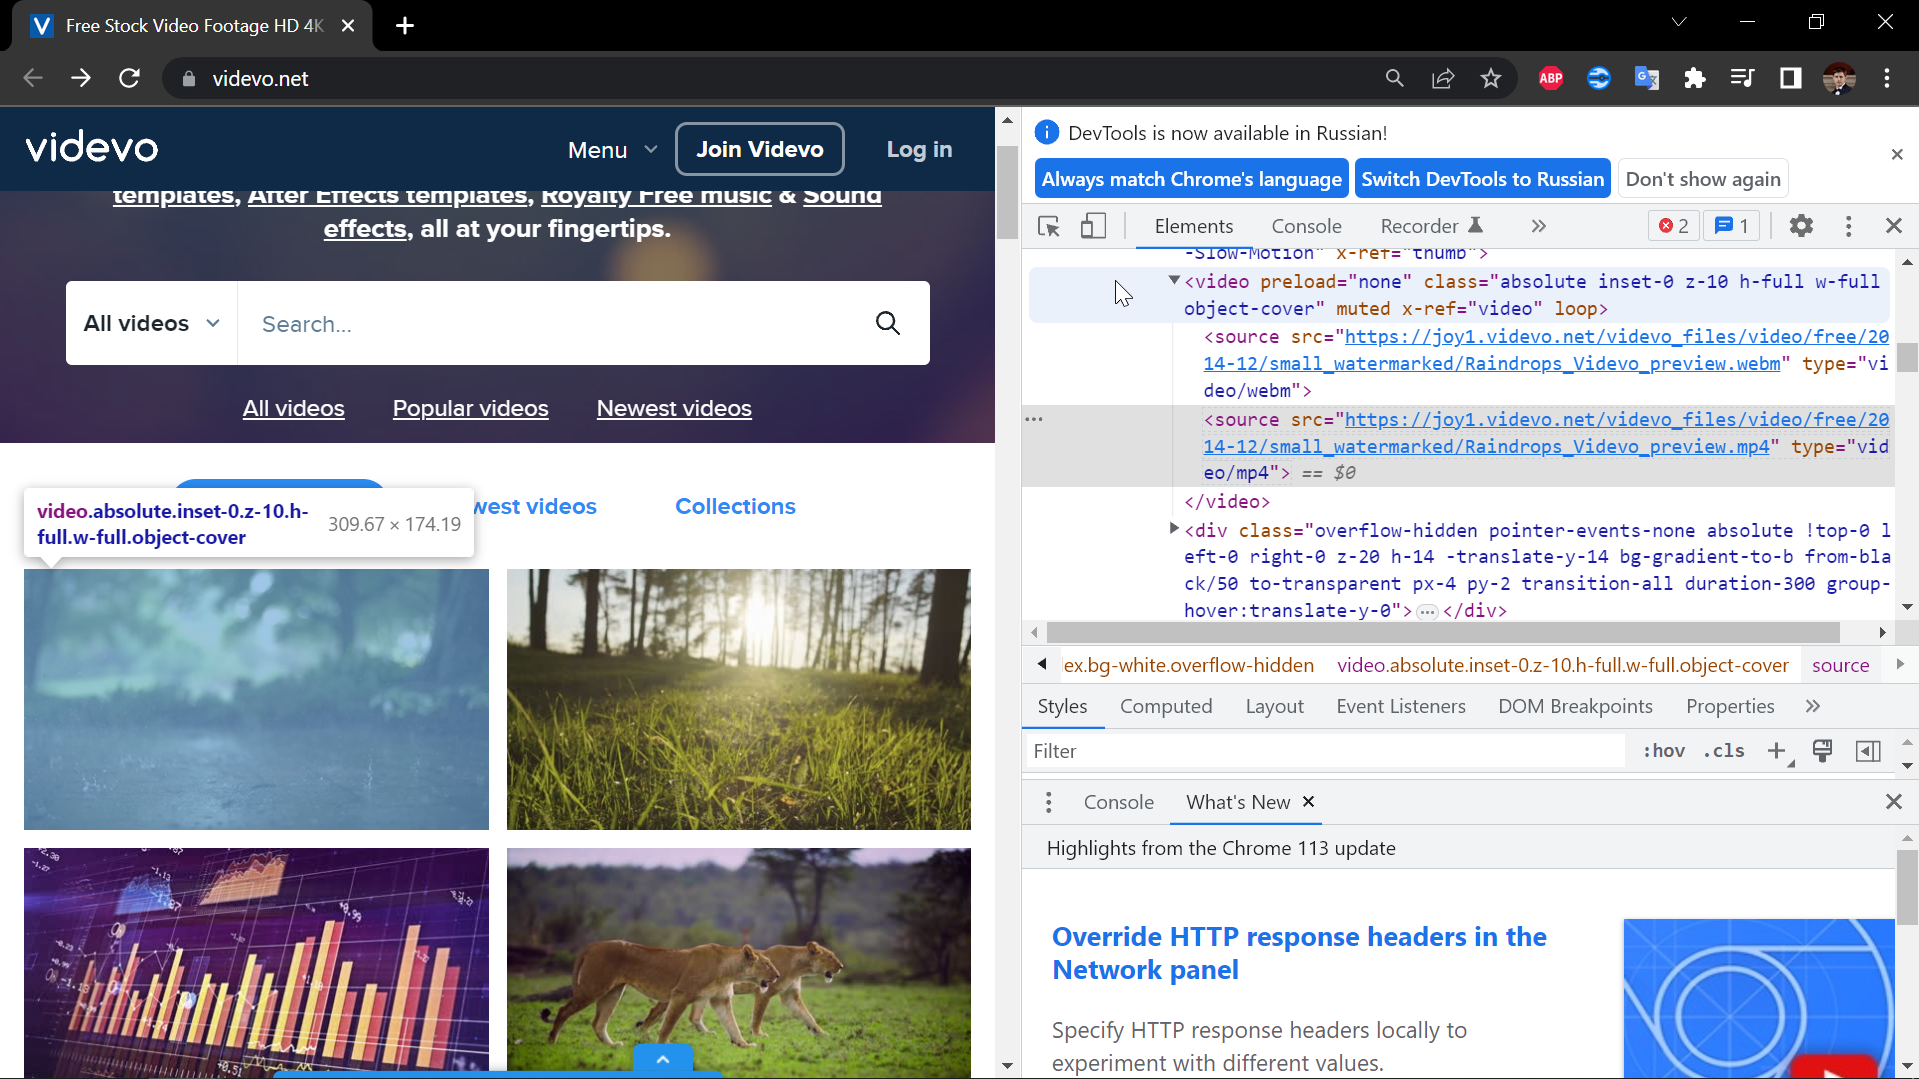

In [ ]:
# <source src="https://joy1.videvo.net/..." type="video/mp4">
allvid = bs.findAll('source', type="video/mp4")
allvid

[<source src="https://resources.videvo.net/wp-content/themes/ViDEVO/home-videos/11.mp4" type="video/mp4"/>,
 <source src="https://joy1.videvo.net/videvo_files/video/free/2014-12/small_watermarked/Raindrops_Videvo_preview.mp4" type="video/mp4"/>,
 <source src="https://joy.videvo.net/videvo_files/video/premium/partners0056/small_watermarked/BB_c24a8e83-7be2-45d2-83bf-916950d6aa48_preview.mp4" type="video/mp4"/>,
 <source src="https://joy1.videvo.net/videvo_files/video/free/video0461/small_watermarked/_import_60e0167b4c3a96.14254367_preview.mp4" type="video/mp4"/>,
 <source src="https://joy.videvo.net/videvo_files/video/premium/video0236/small_watermarked/NO%20MR_STOCK%20FOOTAGE%20NO%20MR%20%28962%29_preview.mp4" type="video/mp4"/>,
 <source src="https://joy1.videvo.net/videvo_files/video/free/2019-09/small_watermarked/190828_27_SuperTrees_HD_17_preview.mp4" type="video/mp4"/>,
 <source src="https://joy.videvo.net/videvo_files/video/premium/video0236/small_watermarked/NO%20MR_STOCK%20FOOT

Скачаем первые 3 видео по ссылкам

In [ ]:
# номер видео
num = 1

# проходим по всем объектам списка allvid
for vid in allvid[:3]:

  # достаем ссылку на видеофайл
  video_url = vid.attrs.get("src")

  # get запрос
  filename = requests.get(video_url)

  # сохраняем видео в файл
  with open(f'video_{num}.mp4', "wb") as out:
    out.write(filename.content)

  num+=1

## Selenium

### Установка Selenium в colab

> Для нормальной работы selenium в colab запустите следующую ячейку с установкой всех необходимых библиотек и параметров

In [ ]:
%%shell

# Эта команда создает файл /etc/apt/sources.list.d/debian.list и записывает в него три строки с адресами репозиториев Debian
cat > /etc/apt/sources.list.d/debian.list <<'EOF'
deb [arch=amd64 signed-by=/usr/share/keyrings/debian-buster.gpg] http://deb.debian.org/debian buster main
deb [arch=amd64 signed-by=/usr/share/keyrings/debian-buster-updates.gpg] http://deb.debian.org/debian buster-updates main
deb [arch=amd64 signed-by=/usr/share/keyrings/debian-security-buster.gpg] http://deb.debian.org/debian-security buster/updates main
EOF

# Эти команды получают ключи для подписи репозиториев с помощью команды apt-key adv
apt-key adv --keyserver keyserver.ubuntu.com --recv-keys DCC9EFBF77E11517
apt-key adv --keyserver keyserver.ubuntu.com --recv-keys 648ACFD622F3D138
apt-key adv --keyserver keyserver.ubuntu.com --recv-keys 112695A0E562B32A

# Эти команды экспортируют ключи в формате gpg и сохраняют их в папке /usr/share/keyrings
apt-key export 77E11517 | gpg --dearmour -o /usr/share/keyrings/debian-buster.gpg
apt-key export 22F3D138 | gpg --dearmour -o /usr/share/keyrings/debian-buster-updates.gpg
apt-key export E562B32A | gpg --dearmour -o /usr/share/keyrings/debian-security-buster.gpg


# Эта команда создает файл /etc/apt/preferences.d/chromium.pref и записывает в него шесть строк с настройками приоритетов для пакетов
cat > /etc/apt/preferences.d/chromium.pref << 'EOF'
Package: *
Pin: release a=eoan
Pin-Priority: 500


Package: *
Pin: origin "deb.debian.org"
Pin-Priority: 300


Package: chromium*
Pin: origin "deb.debian.org"
Pin-Priority: 700
EOF


# Эта команда обновляет список пакетов с помощью команды apt-get update
apt-get update

# Эта команда устанавливает пакеты chromium и chromium-driver с помощью команды apt-get install
apt-get install chromium chromium-driver


# Эта команда устанавливает модуль selenium для Python с помощью команды pip install
pip install selenium

Executing: /tmp/apt-key-gpghome.A6poMWquKl/gpg.1.sh --keyserver keyserver.ubuntu.com --recv-keys DCC9EFBF77E11517
gpg: key DCC9EFBF77E11517: public key "Debian Stable Release Key (10/buster) <debian-release@lists.debian.org>" imported
gpg: Total number processed: 1
gpg:               imported: 1
Executing: /tmp/apt-key-gpghome.yxvAKbd9iz/gpg.1.sh --keyserver keyserver.ubuntu.com --recv-keys 648ACFD622F3D138
gpg: key DC30D7C23CBBABEE: public key "Debian Archive Automatic Signing Key (10/buster) <ftpmaster@debian.org>" imported
gpg: Total number processed: 1
gpg:               imported: 1
Executing: /tmp/apt-key-gpghome.XKIFcSQXQv/gpg.1.sh --keyserver keyserver.ubuntu.com --recv-keys 112695A0E562B32A
gpg: key 4DFAB270CAA96DFA: public key "Debian Security Archive Automatic Signing Key (10/buster) <ftpmaster@debian.org>" imported
gpg: Total number processed: 1
gpg:               imported: 1
Get:1 http://deb.debian.org/debian buster InRelease [122 kB]
Get:2 http://deb.debian.org/debian bust

**Для версии хром 116.0.5845.96 обновляем версию chromedriver.**

https://googlechromelabs.github.io/chrome-for-testing/#stable

https://googlechromelabs.github.io/chrome-for-testing/known-good-versions-with-downloads.json


In [ ]:
# Загрузка ZIP-архива по указанной ссылке.
!wget -q https://edgedl.me.gvt1.com/edgedl/chrome/chrome-for-testing/116.0.5845.96/linux64/chromedriver-linux64.zip -O /content/chromedriver-linux64.zip
# Распаковка файлов из архива в указанную директорию.
!unzip -o -qq /content/chromedriver-linux64.zip -d /content
!cp /content/chromedriver-linux64/chromedriver /usr/bin

Для корректной работы в colab (при использовании браузера chrome) создание `driver` выполняется как в ячейке ниже

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options

# параметры для слздания экземпляра webdriver
options = Options()
options.add_argument("--headless")
options.add_argument("--no-sandbox")
options.headless = True

# создаем экземпляр webdriver для работы в Chrome
driver = webdriver.Chrome(options=options)

<ipython-input-48-7dc1af57e9ac>:8: DeprecationWarning: headless property is deprecated, instead use add_argument('--headless') or add_argument('--headless=new')
  options.headless = True


### Начало работы с Selenium

В качестве примера выполним парсинг текста стихотворения

"https://rustih.ru/fedor-tyutchev-zima-nedarom-zlitsya/"

In [ ]:
# ссылка на страницу
url = "https://rustih.ru/fedor-tyutchev-zima-nedarom-zlitsya/"

# запрос на страницу
driver.get(url)

# код страницы
print(driver.page_source)

<html lang="ru" prefix="og: http://ogp.me/ns#"><head>
<meta http-equiv="x-dns-prefetch-control" content="on">
<link href="//googleads.g.doubleclick.net" rel="dns-prefetch">
<link href="//pagead2.googlesyndication.com" rel="dns-prefetch">
<link href="//ajax.googleapis.com" rel="dns-prefetch">
<link href="//tpc.googlesyndication.com" rel="dns-prefetch">
<link href="//googleads.g.doubleclick.net" rel="preconnect">
<link href="//pagead2.googlesyndication.com" rel="preconnect">
<link href="//ajax.googleapis.com" rel="preconnect">
<link href="//tpc.googlesyndication.com" rel="preconnect">
<script async="" src="//cse.google.com/adsense/search/async-ads.js"></script><script type="text/javascript" async="" src="https://www.googletagmanager.com/gtag/js?id=G-MY4Y5CMS2V&amp;l=dataLayer&amp;cx=c"></script><script type="text/javascript" async="" src="https://cse.google.com/cse.js?cx=015197505683698623428:zn2d60qadny"></script><script async="" src="https://cdn.jsdelivr.net/npm/yandex-metrica-watch/ta

### Поиск элементов

Для поиска элементов страницы используются функции `find_element()` или `find_elements()`. Функция `find_element()` вернёт первый найденный элемент, в то время как `find_elements()` вернёт список всех найденных элементов.

Класс `By` используется для указания атрибута поиска элементов на странице. Варианты классов для поиска:

    find_element(By.ID, "id")
    find_element(By.NAME, "name")
    find_element(By.XPATH, "xpath")
    find_element(By.LINK_TEXT, "link text")
    find_element(By.PARTIAL_LINK_TEXT, "partial link text")
    find_element(By.TAG_NAME, "tag name")
    find_element(By.CLASS_NAME, "class name")
    find_element(By.CSS_SELECTOR, "css selector")

In [ ]:
from selenium.webdriver.common.by import By

# ссылка на страницу
url = "https://rustih.ru/fedor-tyutchev-zima-nedarom-zlitsya/"

# запрос на страницу
driver.get(url)

# поиск класса с именем 'entry-content.poem-text'
bt = driver.find_element(By.CLASS_NAME, 'entry-content.poem-text')
print(bt.text)

Зима недаром злится,
Прошла ее пора —
Весна в окно стучится
И гонит со двора.
И все засуетилось,
Все нудит Зиму вон —
И жаворонки в небе
Уж подняли трезвон.
Зима еще хлопочет
И на Весну ворчит.
Та ей в глаза хохочет
И пуще лишь шумит…
Взбесилась ведьма злая
И, снегу захватя,
Пустила, убегая,
В прекрасное дитя…
Весне и горя мало:
Умылася в снегу,
И лишь румяней стала,
Наперекор врагу.
Анализ стихотворения «Зима недаром злится, прошла ее пора» Тютчева
Ф. Тютчев долгое время не публиковал своих стихотворений. Находясь на дипломатической службе и являясь уважаемым и обеспеченным человеком, он считал свои литературные творения забавой и способом отвлечься от серьезных государственных дел. К публикации своих стихов его вынудили настойчивые просьбы друзей, которые высоко оценили талант начинающего поэта. Среди таких «легких» набросков оказалось стихотворение «Зима недаром злится…» (1836 г.), которое Тютчев включил в послание своему товарищу. Оно так и не было опубликовано при жизни поэта.
Отл

In [ ]:
# поиск класса с именем 'entry-content.poem-text'
bt2 = driver.find_element(By.XPATH, '//*[@id="main"]/article/div[5]')
print(bt2.text)

Зима недаром злится,
Прошла ее пора —
Весна в окно стучится
И гонит со двора.
И все засуетилось,
Все нудит Зиму вон —
И жаворонки в небе
Уж подняли трезвон.
Зима еще хлопочет
И на Весну ворчит.
Та ей в глаза хохочет
И пуще лишь шумит…
Взбесилась ведьма злая
И, снегу захватя,
Пустила, убегая,
В прекрасное дитя…
Весне и горя мало:
Умылася в снегу,
И лишь румяней стала,
Наперекор врагу.
Анализ стихотворения «Зима недаром злится, прошла ее пора» Тютчева
Ф. Тютчев долгое время не публиковал своих стихотворений. Находясь на дипломатической службе и являясь уважаемым и обеспеченным человеком, он считал свои литературные творения забавой и способом отвлечься от серьезных государственных дел. К публикации своих стихов его вынудили настойчивые просьбы друзей, которые высоко оценили талант начинающего поэта. Среди таких «легких» набросков оказалось стихотворение «Зима недаром злится…» (1836 г.), которое Тютчев включил в послание своему товарищу. Оно так и не было опубликовано при жизни поэта.
Отл

Оставим только текст стихотворения

In [ ]:
print(bt.text.split('Анализ стихотворения')[0])

Зима недаром злится,
Прошла ее пора —
Весна в окно стучится
И гонит со двора.
И все засуетилось,
Все нудит Зиму вон —
И жаворонки в небе
Уж подняли трезвон.
Зима еще хлопочет
И на Весну ворчит.
Та ей в глаза хохочет
И пуще лишь шумит…
Взбесилась ведьма злая
И, снегу захватя,
Пустила, убегая,
В прекрасное дитя…
Весне и горя мало:
Умылася в снегу,
И лишь румяней стала,
Наперекор врагу.



<h2>HH.RU</h2>

Парсим вакансии тестировщка

https://hh.ru/search/vacancy?text=%D0%A2%D0%B5%D1%81%D1%82%D0%B8%D1%80%D0%BE%D0%B2%D1%89%D0%B8%D0%BA

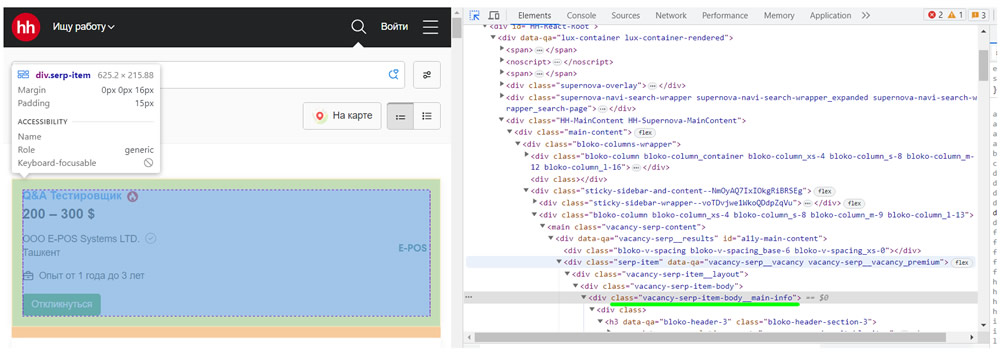

In [ ]:
from selenium.webdriver.common.by import By

# ссылка на страницу
url = "https://hh.ru/search/vacancy?text=%D0%A2%D0%B5%D1%81%D1%82%D0%B8%D1%80%D0%BE%D0%B2%D1%89%D0%B8%D0%BA"

# запрос на страницу
driver.get(url)


# поиск класса с именем 'vacancy-serp-item-body__main-info'
bt = driver.find_elements(By.CLASS_NAME, 'vacancy-serp-item-body__main-info')
print('Количестов товаров:', len(bt))
k = 0
for i in bt:
  print()
  print(k, ") ", i.text)
  k=k+1

Количестов товаров: 52

0 )  Тестировщик
до 70 000 ₽
Door 407
Зеленоград

1 )  Креативный копирайтер / Автор вопросов для барной викторины
от 30 000 ₽
Ruda Games
Екатеринбург

2 )  Тестировщик (удаленно)
от 120 000 ₽
NodaSoft
Москва

3 )  Project Manager
800 – 2 000 $
ООО MODERN TECH PLANET
Ташкент

4 )  Q&A Тестировщик
200 – 300 $
ООО E-POS Systems LTD.
Ташкент

5 )  Менеджер по продажам
12 000 000 – 17 000 000 so'm
т.м AB.Digital (ООО Bazis Digital)
Ташкент

6 )  Senior QA Engineer (remote/удалённо)
100 000 – 200 000 ₽
Fashion Cute LLC, Представительство
Москва, Библиотека им.Ленина и еще 3 

7 )  Manual QA Engineer (Intern) / Тестировщик игр (Стажер)
ООО G-CORE TOSHKENT
Ташкент

8 )  Manual QA Engineer (Junior)
ООО G-CORE TOSHKENT
Ташкент

9 )  Руководитель ИТ-проектов (Middle/Senior) (Москва)
199 500 – 300 000 ₽
ООО Тагес Джамп
Москва, Автозаводская и еще 2 

10 )  Laravel программист / Back-end разработчик (удалённо)
130 000 – 150 000 ₽
ИП Костина Екатерина Олеговна
Москва

11 )  

<h2>AVITO.RU</h2>

Парсим модельки машин 1:43

https://www.avito.ru/yaroslavskaya_oblast?cd=1&q=%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D1%8C+%D0%B0%D0%B2%D1%82%D0%BE%D0%BC%D0%BE%D0%B1%D0%B8%D0%BB%D1%8F+1+43

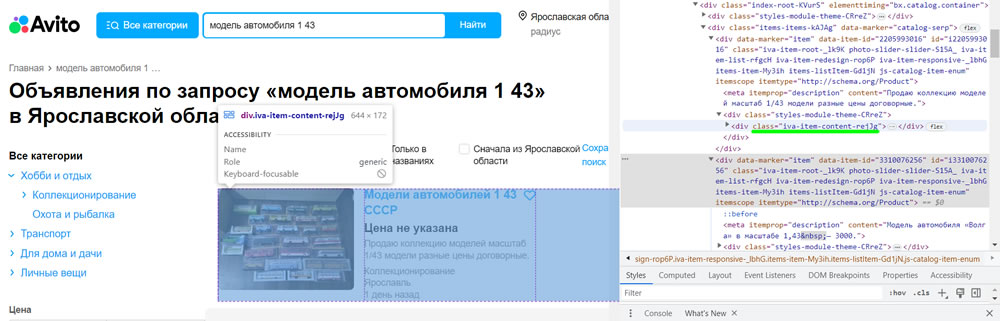

In [ ]:
from selenium.webdriver.common.by import By

# ссылка на страницу
url = "https://www.avito.ru/yaroslavskaya_oblast?cd=1&q=%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D1%8C+%D0%B0%D0%B2%D1%82%D0%BE%D0%BC%D0%BE%D0%B1%D0%B8%D0%BB%D1%8F+1+43"

# запрос на страницу
driver.get(url)


# поиск класса с именем 'iva-item-content-rejJg'
bt = driver.find_elements(By.CLASS_NAME, 'iva-item-content-rejJg')
print('Количестов товаров:', len(bt))
k = 0
for i in bt:
  print()
  print(k, ") ", i.text)
  k=k+1

Количестов товаров: 70

0 )  Модели автомобилей 1 43 СССР
Цена не указана
Продаю коллекцию моделей масштаб 1/43 модели разные цены договорные.
Коллекционирование
Ярославль
4 дня назад

1 )  Модель автомобиля "Волга" в масштабе 1,43
3 000 ₽
Модель автомобиля «Волга» в масштабе 1,43 — 3000.
Коллекционирование
Ярославль
2 дня назад

2 )  Модели авто Mercedes Benz,Мерседес Бенц 1/43
350 ₽
Масштаб 1/43. Цены от 300 руб, см. Список: Mercedes Benz A Class (2006), New Ray, 350 руб. Mercedes Benz SL 190, Bauer/Cararama/Hongwell, 750 руб. Mercedes Benz 450 sel W116 Милиция, полицейские машины мира №22, 1500 руб. Mercedes Benz Slr Mclaren, Motor Max, 400 руб. Maybach 62 Long 2003, Суперкары №78, 600 руб. Mercedes Benz G klass Gelandewagen Гелендваген, Bauer/Cararama/Hongwell, 700 руб. Mercedes Benz L1000 «Express» (1929), Premium Classixxs, 3500 руб. Mercedes Benz 200V G5 (W152) Вермaxт 1938, Ixo, лобовое стекло приклеено, 1100 руб. Mercedes Benz Unimog 406, 1200 руб. Отправляю почтой, Авито дост